In [125]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objects as go

df = sns.load_dataset("mpg")

In [126]:
sns.set_theme(style="whitegrid")

In [127]:
# 1. Carga `auto_mpg.csv` y realiza el primer contacto con el dataset. Reporta dimensiones,
# primeras filas, tipos de datos y define qué representa una fila.
# Pista de trabajo: `shape`, `head()`, `info()` y `dtypes`.
df.shape

(398, 9)

In [128]:
df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [130]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

In [131]:
# 2. Clasifica `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`,
# `model_year`, `origin` y `name`. Identifica qué variables, aunque puedan verse numéricas,
# conviene tratar como categorías o variables temporales.
# Pista de trabajo: El significado de una variable es más importante que su dtype.
clasificacion_variables=pd.DataFrame({
    "variable":["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year","origin","name"],
    "clasificacion":[
        "numerica - continua",
        "numerica - discreta",
        "numerica - continua",
        "numerica - continua",
        "numerica - continua",
        "numerica - continua",
        "numerica - discreta",
        "categorica - nominal",
        "categorica - nominal"
    ]
})
clasificacion_variables

,variable,clasificacion
0,mpg,numerica - continua
1,cylinders,numerica - discreta
2,displacement,numerica - continua
3,horsepower,numerica - continua
4,weight,numerica - continua
5,acceleration,numerica - continua
6,model_year,numerica - discreta
7,origin,categorica - nominal
8,name,categorica - nominal


In [132]:
df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [133]:
# 3. Analiza valores faltantes y duplicados exactos. ¿En qué variable faltan datos y qué
# proporción representan?
# Pista de trabajo: Para una correlación puntual puedes trabajar con pares completos sin alterar toda la tabla.

valores_nulas= pd.DataFrame({
    "numero_nulos":df.isna().sum(),
    "porcentaje": df.isna().mean()*100
}).sort_values("porcentaje",ascending=False)
valores_nulas

,numero_nulos,porcentaje
horsepower,6,1.507538
mpg,0,0.000000
cylinders,0,0.000000
displacement,0,0.000000
weight,0,0.000000
acceleration,0,0.000000
model_year,0,0.000000
origin,0,0.000000
name,0,0.000000


In [134]:
num_duplicados=df.duplicated().sum()

duplicados=df[df.duplicated(keep=False)].sort_values(list(df.columns))
duplicados.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name


In [135]:
duplicados.shape

(0, 9)

In [136]:
# 4. Estudia la cardinalidad de `name`. ¿Cuántos nombres distintos hay? ¿Que un nombre
# aparezca varias veces significa que las filas son duplicadas? Compruébalo con ejemplos.
# Pista de trabajo: Un mismo modelo de automóvil puede aparecer en años o configuraciones diferentes.

df.sort_values("name",ascending=True).head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
96,13.0,8,360.0,175.0,3821,11.0,73,usa,amc ambassador brougham
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl
66,17.0,8,304.0,150.0,3672,11.5,72,usa,amc ambassador sst
315,24.3,4,151.0,90.0,3003,20.1,80,usa,amc concord
257,19.4,6,232.0,90.0,3210,17.2,78,usa,amc concord
261,18.1,6,258.0,120.0,3410,15.1,78,usa,amc concord d/l
374,23.0,4,151.0,NaN,3035,20.5,82,usa,amc concord dl
283,20.2,6,232.0,90.0,3265,18.2,79,usa,amc concord dl 6
107,18.0,6,232.0,100.0,2789,15.0,73,usa,amc gremlin
33,19.0,6,232.0,100.0,2634,13.0,71,usa,amc gremlin


In [137]:
valores_nombre=df["name"].value_counts()
valores_nombre

name
ford pinto          6
ford maverick       5
amc matador         5
toyota corolla      5
chevrolet impala    4
                   ..
ford mustang gl     1
vw pickup           1
dodge rampage       1
ford ranger         1
chevy s-10          1
Name: count, Length: 305, dtype: int64

In [138]:
# 5. Calcula estadísticos descriptivos de `mpg`, `weight` y `horsepower`: media, mediana,
# desviación estándar, cuartiles e IQR. Interpreta qué te dicen sobre un automóvil “típico” y
# sobre la dispersión.
# Pista de trabajo: Compara medidas sensibles y robustas frente a valores extremos.

resumen=df[["mpg","weight","horsepower"]].agg(["mean","median","std"])
print(resumen)

q=df[["mpg","weight","horsepower"]].quantile([0.25,0.75]).T
q.columns=["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]
print(q)

              mpg       weight  horsepower
mean    23.514573  2970.424623  104.469388
median  23.000000  2803.500000   93.500000
std      7.815984   846.841774   38.491160
                 q1      q3      iqr
mpg           17.50    29.0    11.50
weight      2223.75  3608.0  1384.25
horsepower    75.00   126.0    51.00


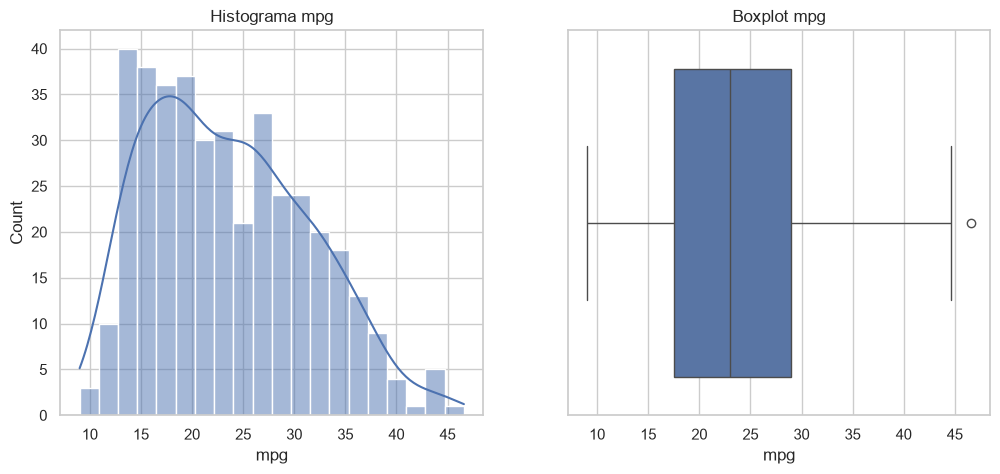

In [139]:
# 6. Analiza la distribución de `mpg` con histograma y KDE.
fig, axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=df,x="mpg",bins=20,kde=True,ax=axes[0])
axes[0].set_title("Histograma mpg")

sns.boxplot(data=df,x="mpg",ax=axes[1])
axes[1].set_title("Boxplot mpg")


plt.show()

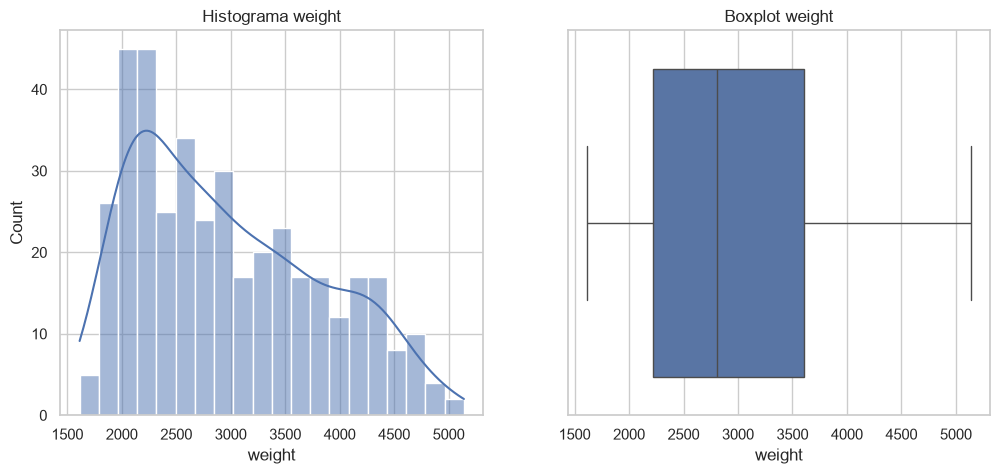

In [140]:
# 7. Analiza `weight` con histograma y boxplot. ¿La distribución es simétrica? ¿Hay valores
# extremos según la regla del IQR? Documenta el cálculo.
# Pista de trabajo: Calcula Q1, Q3, IQR y límites inferior/superior.

fig, axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=df,x="weight",bins=20,kde=True,ax=axes[0])
axes[0].set_title("Histograma weight")

sns.boxplot(data=df,x="weight",ax=axes[1])
axes[1].set_title("Boxplot weight")


plt.show()

horsepower   -1.5
dtype: float64
horsepower    202.5
dtype: float64


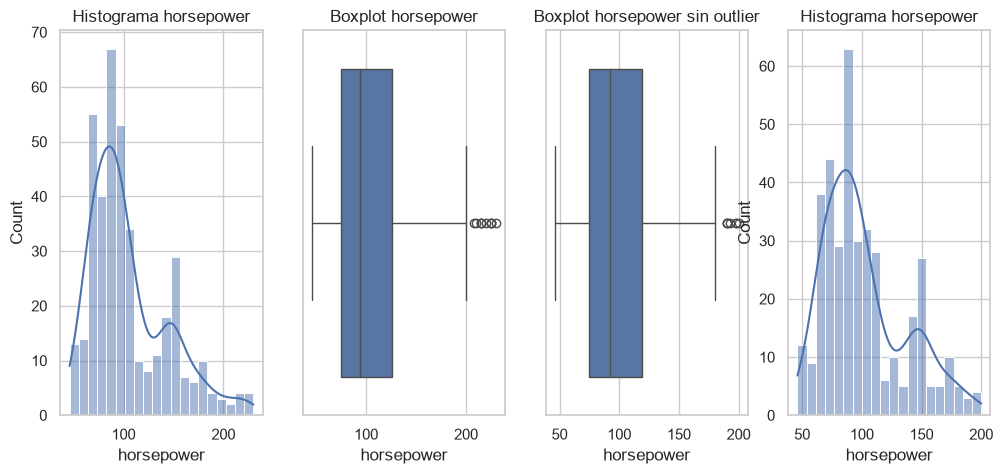

                             name  horsepower
6                chevrolet impala       220.0
7               plymouth fury iii       215.0
8                pontiac catalina       225.0
13        buick estate wagon (sw)       225.0
25                      ford f250       215.0
27                     dodge d200       210.0
67                mercury marquis       208.0
94   chrysler new yorker brougham       215.0
95       buick electra 225 custom       225.0
116            pontiac grand prix       230.0


In [141]:
# 8. Detecta outliers en `horsepower` usando 1.5·IQR. Lista los vehículos identificados y
# comenta si parecen errores evidentes o automóviles de alta potencia plausibles.
# Pista de trabajo: Conserva el nombre del vehículo para interpretar el contexto del outlier.

fig, axes=plt.subplots(1,4,figsize=(12,5))
sns.histplot(data=df,x="horsepower",bins=20,kde=True,ax=axes[0])
axes[0].set_title("Histograma horsepower")

sns.boxplot(data=df,x="horsepower",ax=axes[1])
axes[1].set_title("Boxplot horsepower")

# Quitar outliers cuando la campana no es simetrica
q=df[["horsepower"]].quantile([0.25,0.75]).T
q.columns=["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]

lower=q["q1"]-1.5*q["iqr"]
print(lower)

upper=q["q3"]+1.5*q["iqr"]
print(upper)

# Aun quedan valores pero estan ya son valores de la data ya reducida
df_sin_outlier=df[(df["horsepower"]>=lower["horsepower"])&(df["horsepower"]<=upper["horsepower"])]
sns.boxplot(data=df_sin_outlier,x="horsepower",ax=axes[2])
axes[2].set_title("Boxplot horsepower sin outlier")

sns.histplot(data=df_sin_outlier,x="horsepower",bins=20,kde=True,ax=axes[3])
axes[3].set_title("Histograma horsepower")
plt.show()

outliers = df[
    (df["horsepower"] < lower["horsepower"]) |
    (df["horsepower"] > upper["horsepower"])
]

print(outliers[["name", "horsepower"]])

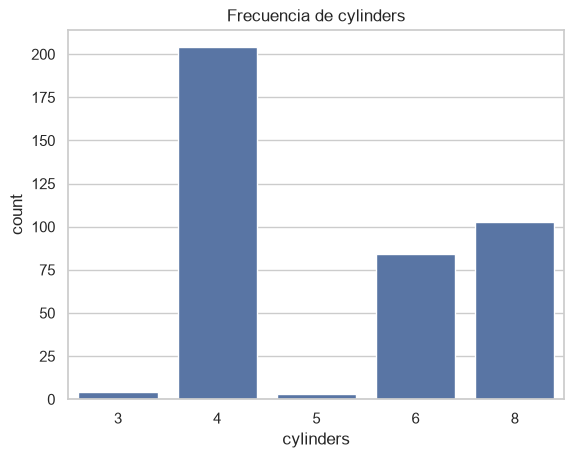

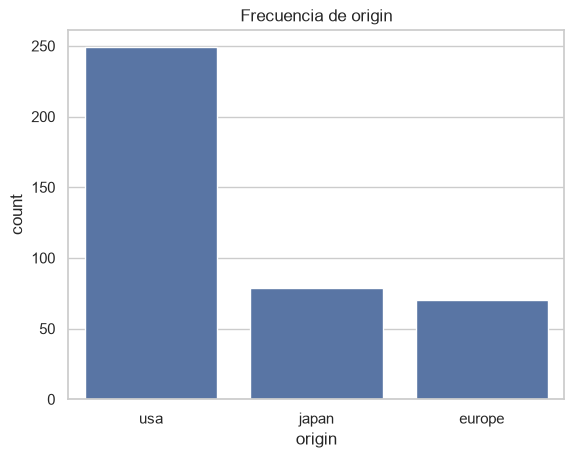

In [142]:
# 9. Explora `cylinders` y `origin` mediante frecuencias y gráficos de barras. ¿Qué categorías
# dominan el dataset? ¿Hay categorías con muy pocos casos?
# Pista de trabajo: Las categorías poco frecuentes pueden hacer inestables algunas comparaciones.

for col in ["cylinders","origin"]:
    sns.countplot(data=df,x=col)
    plt.title(f"Frecuencia de {col}")
    plt.show()

           count       mean  median       std
cylinders                                    
3              4  20.550000   20.25  2.564501
4            204  29.286765   28.25  5.710156
5              3  27.366667   25.40  8.228204
6             84  19.985714   19.00  3.807322
8            103  14.963107   14.00  2.836284


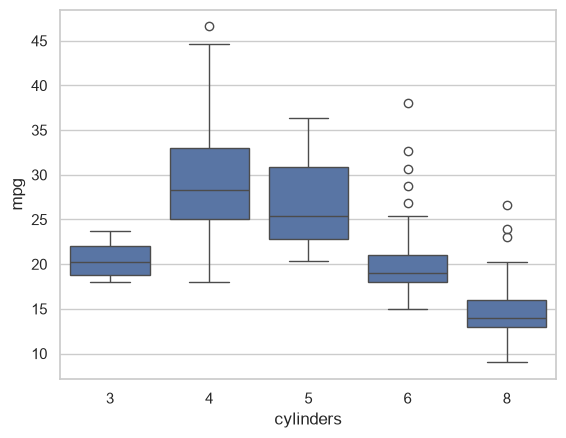

In [143]:
# 10. Compara `mpg` entre vehículos con distinto número de cilindros mediante boxplot y
# medias/medianas por grupo. ¿Qué patrón general observas?---   hay mas datos de cilindros de 4 ,6 , 8 y estos muestran una disminucion  a mas cilindros
# Pista de trabajo: Ordena los cilindros numéricamente.
age_stats=df.groupby("cylinders")["mpg"].agg(["count","mean","median","std"])
print(age_stats)

sns.boxplot(data=df,x="cylinders",y="mpg")
plt.show()


        count       mean  median       std
origin                                    
europe     70  27.891429    26.5  6.723930
japan      79  30.450633    31.6  6.090048
usa       249  20.083534    18.5  6.402892


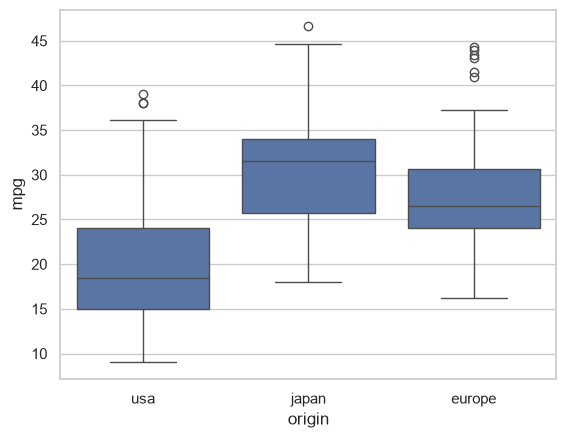

In [144]:
# 11. Compara `mpg` entre los tres orígenes del dataset. Usa boxplot y estadísticas por grupo.
# Pista de trabajo: Las diferencias de origen pueden estar mezcladas con peso, cilindrada, año y otras
# variables.
age_stats=df.groupby("origin")["mpg"].agg(["count","mean","median","std"])
print(age_stats)

sns.boxplot(data=df,x="origin",y="mpg")
plt.show()


In [145]:
stats = df.groupby("origin")[
    ["mpg", "weight", "displacement", "horsepower", "acceleration", "model_year","cylinders"]
].mean()

print(stats)

              mpg       weight  displacement  horsepower  acceleration  \
origin                                                                   
europe  27.891429  2423.300000    109.142857   80.558824     16.787143   
japan   30.450633  2221.227848    102.708861   79.835443     16.172152   
usa     20.083534  3361.931727    245.901606  119.048980     15.033735   

        model_year  cylinders  
origin                         
europe   75.814286   4.157143  
japan    77.443038   4.101266  
usa      75.610442   6.248996  


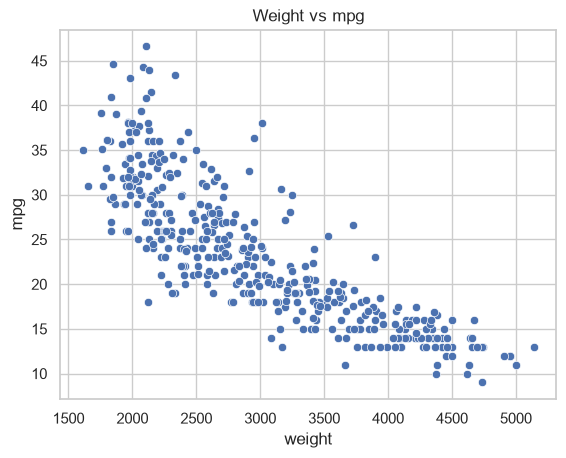

In [146]:
# 12. Estudia la relación entre `weight` y `mpg` con un scatterplot y la correlación.

sns.scatterplot(data=df,x="weight",y="mpg")
plt.title("Weight vs mpg")
plt.show()

In [147]:
correlacion = df["weight"].corr(df["mpg"])

print(correlacion)

-0.8317409332443354


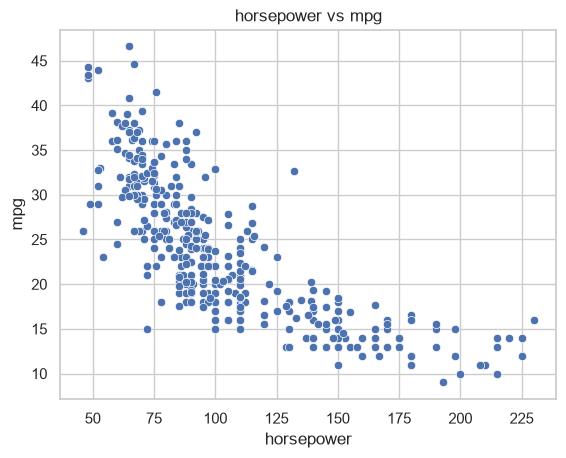

-0.7784267838977761


In [148]:
# 13. Estudia la relación entre `horsepower` y `mpg` con scatterplot y correlación. Compara su
# intensidad con la relación `weight`–`mpg`.
# Pista de trabajo: Trabaja con las filas donde `horsepower` no es nulo.
df_copy=df.copy()
df_copy=df_copy.dropna()
sns.scatterplot(data=df_copy,x="horsepower",y="mpg")
plt.title("horsepower vs mpg")
plt.show()

correlacion = df["horsepower"].corr(df["mpg"])

print(correlacion)

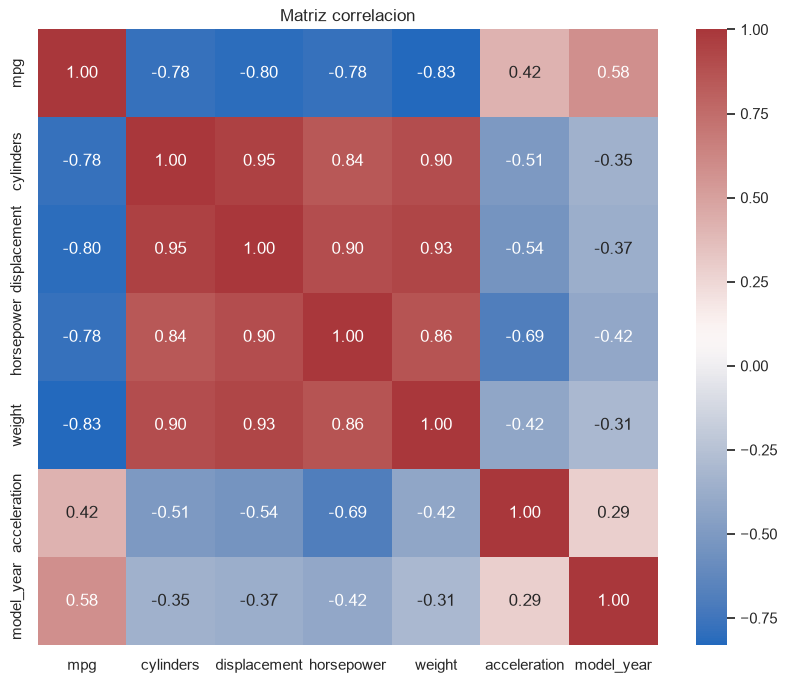

In [149]:
# 14. Construye una matriz de correlación y heatmap de las variables numéricas. Identifica las
# tres variables con mayor asociación lineal absoluta con `mpg` y comenta posibles
# redundancias entre predictores.
# Pista de trabajo: La matriz es simétrica; no hace falta interpretar dos veces cada pareja.

columns_numericas=df.select_dtypes(include="number")
corr=columns_numericas.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="vlag")
plt.title("Matriz correlacion")
plt.show()

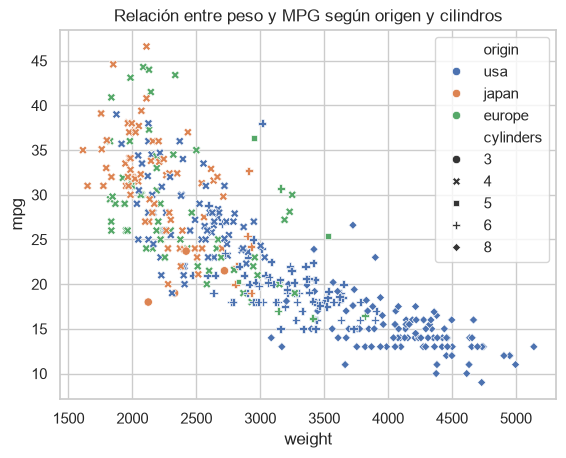

In [150]:
# 15. Realiza un análisis multivariado de `weight` frente a `mpg` incorporando `origin` y
# `cylinders` (mediante color, estilo, facetas u otra codificación). Añade la evolución media de
# `mpg` por `model_year`.
# Pista de trabajo: Busca si el patrón peso–consumo se mantiene dentro de distintos grupos y cómo cambia
# con el tiempo.

fig=px.scatter(data_frame=df,x="weight",y="mpg",color="origin",symbol="cylinders")
fig.show()
sns.scatterplot(data=df,x="weight",y="mpg",hue="origin",style="cylinders")
plt.title("Relación entre peso y MPG según origen y cilindros")
plt.show()


    model_year       mean  median
0           70  17.689655   16.00
1           71  21.250000   19.00
2           72  18.714286   18.50
3           73  17.100000   16.00
4           74  22.703704   24.00
5           75  20.266667   19.50
6           76  21.573529   21.00
7           77  23.375000   21.75
8           78  24.061111   20.70
9           79  25.093103   23.90
10          80  33.696552   32.70
11          81  30.334483   31.60
12          82  31.709677   32.00


<Axes: xlabel='model_year', ylabel='mean'>

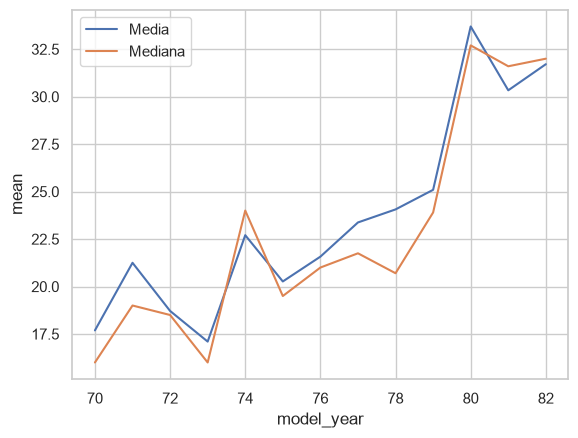

In [151]:
# 16. Analiza la evolución de `mpg` por `model_year`. Calcula media y mediana por año y
# represéntalas en una gráfica de líneas.
# Pista de trabajo: Trata `model_year` como una variable temporal discreta y revisa todos los años, no solo el
# primero y el último.
df_por_anhos=df.groupby("model_year",as_index=False)["mpg"].agg(["mean","median"])
print(df_por_anhos)

sns.lineplot(data=df_por_anhos, x="model_year", y="mean", label="Media")
sns.lineplot(data=df_por_anhos, x="model_year", y="median", label="Mediana")

        count         mean  median         std
origin                                        
europe     70  2423.300000  2240.0  490.043191
japan      79  2221.227848  2155.0  320.497248
usa       249  3361.931727  3365.0  794.792506


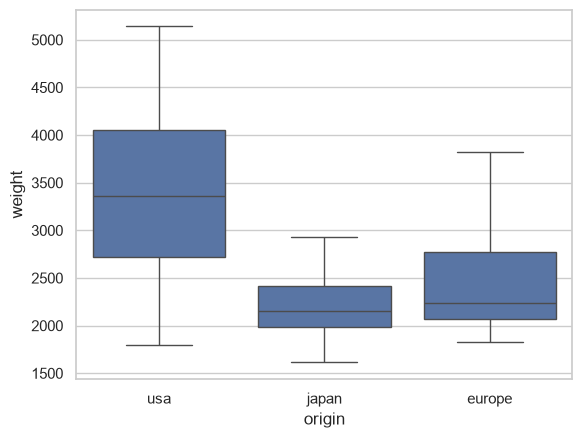

In [152]:
# 17. Compara el `weight` de los automóviles por `origin` mediante estadísticas y boxplots.
# ¿Puede la diferencia de peso ayudar a explicar parte de las diferencias de `mpg` observadas
# entre orígenes?
# Pista de trabajo: Relaciona este resultado con la fuerte asociación entre peso y consumo observada
# previamente.

age_stats=df.groupby("origin")["weight"].agg(["count","mean","median","std"])
print(age_stats)

sns.boxplot(data=df,x="origin",y="weight")
plt.show()

In [153]:
# 18. Estudia el patrón de los valores faltantes de `horsepower`. Compara su frecuencia por
# `origin`, `cylinders` y `model_year`.
# Pista de trabajo: Con pocos casos faltantes conviene describir el patrón, pero evitar conclusiones fuertes.
df_copy=df.copy()

df_copy["horsepower_nulos"]=df_copy["horsepower"].isna()
df_copy.groupby("origin")["horsepower_nulos"].sum()

origin
europe    2
japan     0
usa       4
Name: horsepower_nulos, dtype: int64

In [154]:
df_copy.groupby("cylinders")["horsepower_nulos"].sum()

cylinders
3    0
4    5
5    0
6    1
8    0
Name: horsepower_nulos, dtype: int64

In [155]:
df_copy.groupby("model_year")["horsepower_nulos"].sum()

model_year
70    0
71    1
72    0
73    0
74    1
75    0
76    0
77    0
78    0
79    0
80    2
81    1
82    1
Name: horsepower_nulos, dtype: int64

In [156]:
df_copy["horsepower_nulos"].value_counts()

horsepower_nulos
False    392
True       6
Name: count, dtype: int64

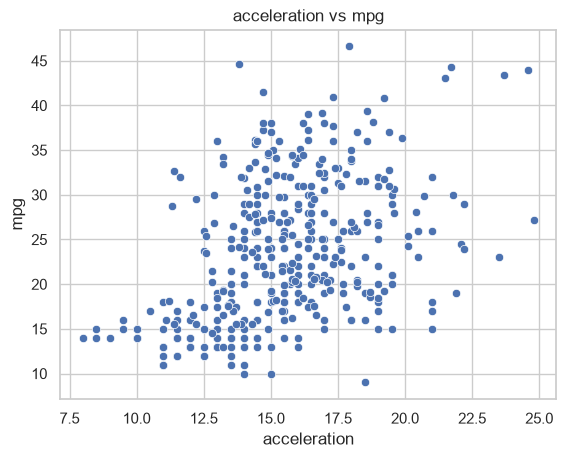

0.42028891210165065


In [157]:
# 19. Analiza la relación entre `acceleration` y `mpg` mediante scatterplot y correlación de
# Pearson. Compara su fuerza con las relaciones de `weight` y `horsepower` con `mpg`.
# Pista de trabajo: Una correlación moderada puede aportar información, pero no necesariamente domina el
# comportamiento del objetivo.


sns.scatterplot(data=df,x="acceleration",y="mpg")
plt.title("acceleration vs mpg")
plt.show()

correlacion = df["acceleration"].corr(df["mpg"])

print(correlacion)

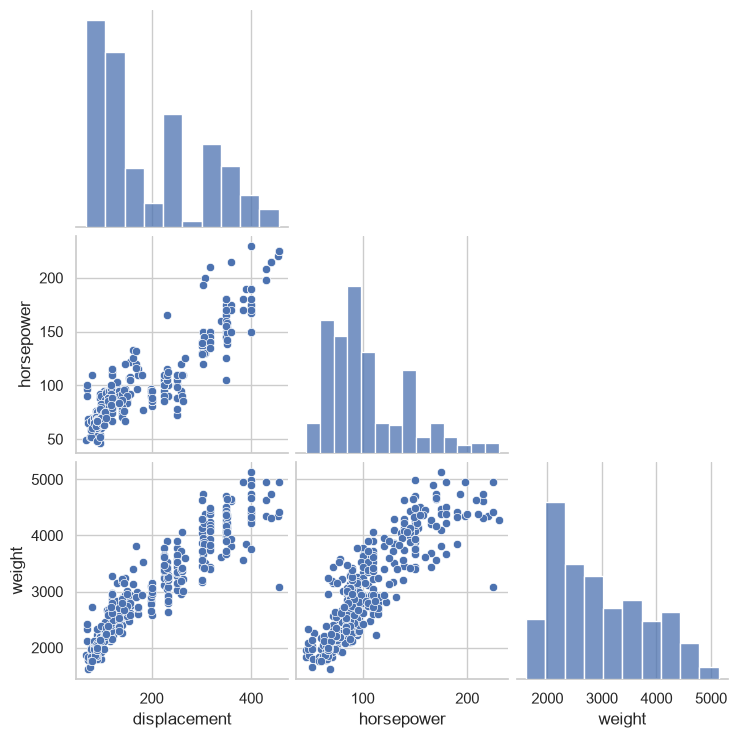

In [158]:
# 20. Explora las relaciones entre `displacement`, `horsepower` y `weight`. Calcula sus
# correlaciones y crea gráficos de dispersión. ¿Qué problema podría aparecer si se usan
# simultáneamente como predictores sin revisar redundancias?
# Pista de trabajo: Correlaciones muy altas entre predictores son una señal de posible multicolinealidad o
# redundancia.

# tienen una correlacion muy alta los tres
pair_plot = df[["displacement", "horsepower", "weight"]].dropna()
sns.pairplot(pair_plot, vars=["displacement", "horsepower", "weight"], corner=True)
plt.show()

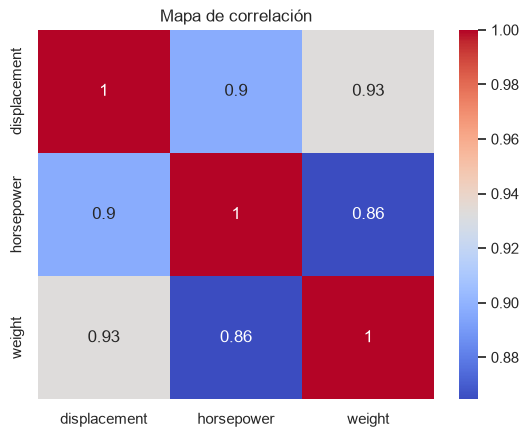

In [159]:
corr = df[["displacement", "horsepower", "weight"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de correlación")
plt.show()

In [160]:
# 21. Construye una tabla pivote con el `mpg` medio por `cylinders` y `origin`, incluyendo el
# número de automóviles por grupo. ¿El patrón de cilindros se mantiene dentro de cada origen?
# Señala grupos con muestras pequeñas.
# Pista de trabajo: No interpretes con la misma confianza una media basada en 3 automóviles que otra basada
# en más de 60.

tabla = pd.pivot_table(df,values="mpg",index="cylinders",columns="origin",aggfunc=["mean", "count"])

print(tabla)


                mean                        count             
origin        europe      japan        usa europe japan    usa
cylinders                                                     
3                NaN  20.550000        NaN    NaN   4.0    NaN
4          28.411111  31.595652  27.840278   63.0  69.0   72.0
5          27.366667        NaN        NaN    3.0   NaN    NaN
6          20.100000  23.883333  19.663514    4.0   6.0   74.0
8                NaN        NaN  14.963107    NaN   NaN  103.0


    model_year  origin       mean  median
0           70  europe  25.200000   25.00
1           70   japan  25.500000   25.50
2           70     usa  15.272727   15.00
3           71  europe  28.750000   29.00
4           71   japan  29.500000   29.00
5           71     usa  18.100000   18.00
6           72  europe  22.000000   22.00
7           72   japan  24.200000   24.00
8           72     usa  16.277778   14.00
9           73  europe  24.000000   24.00
10          73   japan  20.000000   20.00
11          73     usa  15.034483   14.00
12          74  europe  27.000000   26.00
13          74   japan  29.333333   31.00
14          74     usa  18.333333   16.00
15          75  europe  24.500000   24.00
16          75   japan  27.500000   26.50
17          75     usa  17.550000   17.50
18          76  europe  24.250000   26.00
19          76   japan  28.000000   30.00
20          76     usa  19.431818   18.25
21          77  europe  29.250000   29.75
22          77   japan  27.416667 

<Axes: xlabel='model_year', ylabel='mean'>

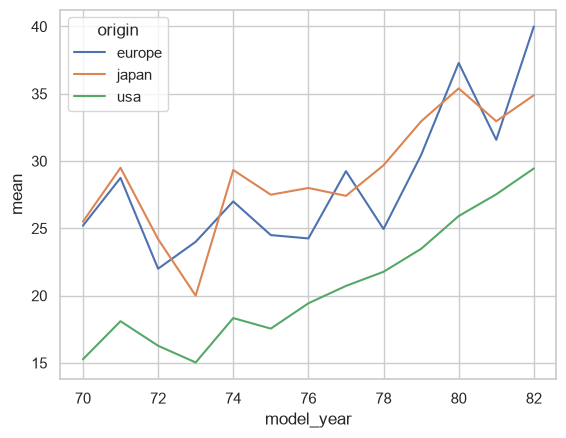

In [161]:
# 22. Compara la evolución temporal de `mpg` entre `origin` usando líneas por grupo. ¿Los tres
# orígenes mejoran con el tiempo? ¿La brecha entre orígenes permanece constante?
# Pista de trabajo: Una gráfica con `model_year` en x, `mpg` medio en y y una línea por origen permite ver
# interacción entre tiempo y origen.

df_por_anhos=df.groupby(["model_year","origin"],as_index=False)["mpg"].agg(["mean","median"])
print(df_por_anhos)

sns.lineplot(data=df_por_anhos, x="model_year", y="mean",hue="origin")



In [162]:
# 23. Compara los outliers de `horsepower` detectados mediante 1.5·IQR y mediante |z| > 3.
# Lista los vehículos más extremos y explica por qué un método puede ser más estricto que el
# otro en una distribución asimétrica.
# Pista de trabajo: Comprueba la intersección entre ambos conjuntos de outliers en lugar de asumir que
# producen la misma lista.

horsepower = df["horsepower"].dropna()
q1, q3 = horsepower.quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

iqr_outs = (df["horsepower"] < lower) | (df["horsepower"] > upper)

print("Total de outliers con IQR:", iqr_outs.sum())

#Utilizando z-score: utilizarlo cuando las distribuciones son simetricas
z = (horsepower - horsepower.mean()) / horsepower.std()
z_outs = z.abs() > 3
print("Total de outliers con z-score:", z_outs.sum())

Total de outliers con IQR: 10
Total de outliers con z-score: 5


In [163]:
iqr_indices = df.index[iqr_outs]
z_indices = z_outs.index[z_outs]

interseccion = iqr_indices.intersection(z_indices)

print("Outliers detectados por ambos métodos:", len(interseccion))

solo_iqr = iqr_indices.difference(z_indices)
solo_z = z_indices.difference(iqr_indices)

print("Solo IQR:")
print(df.loc[solo_iqr, ["name", "horsepower"]])

print("\nSolo Z-score:")
print(df.loc[solo_z, ["name", "horsepower"]])

Outliers detectados por ambos métodos: 5
Solo IQR:
                            name  horsepower
7              plymouth fury iii       215.0
25                     ford f250       215.0
27                    dodge d200       210.0
67               mercury marquis       208.0
94  chrysler new yorker brougham       215.0

Solo Z-score:
Empty DataFrame
Columns: [name, horsepower]
Index: []


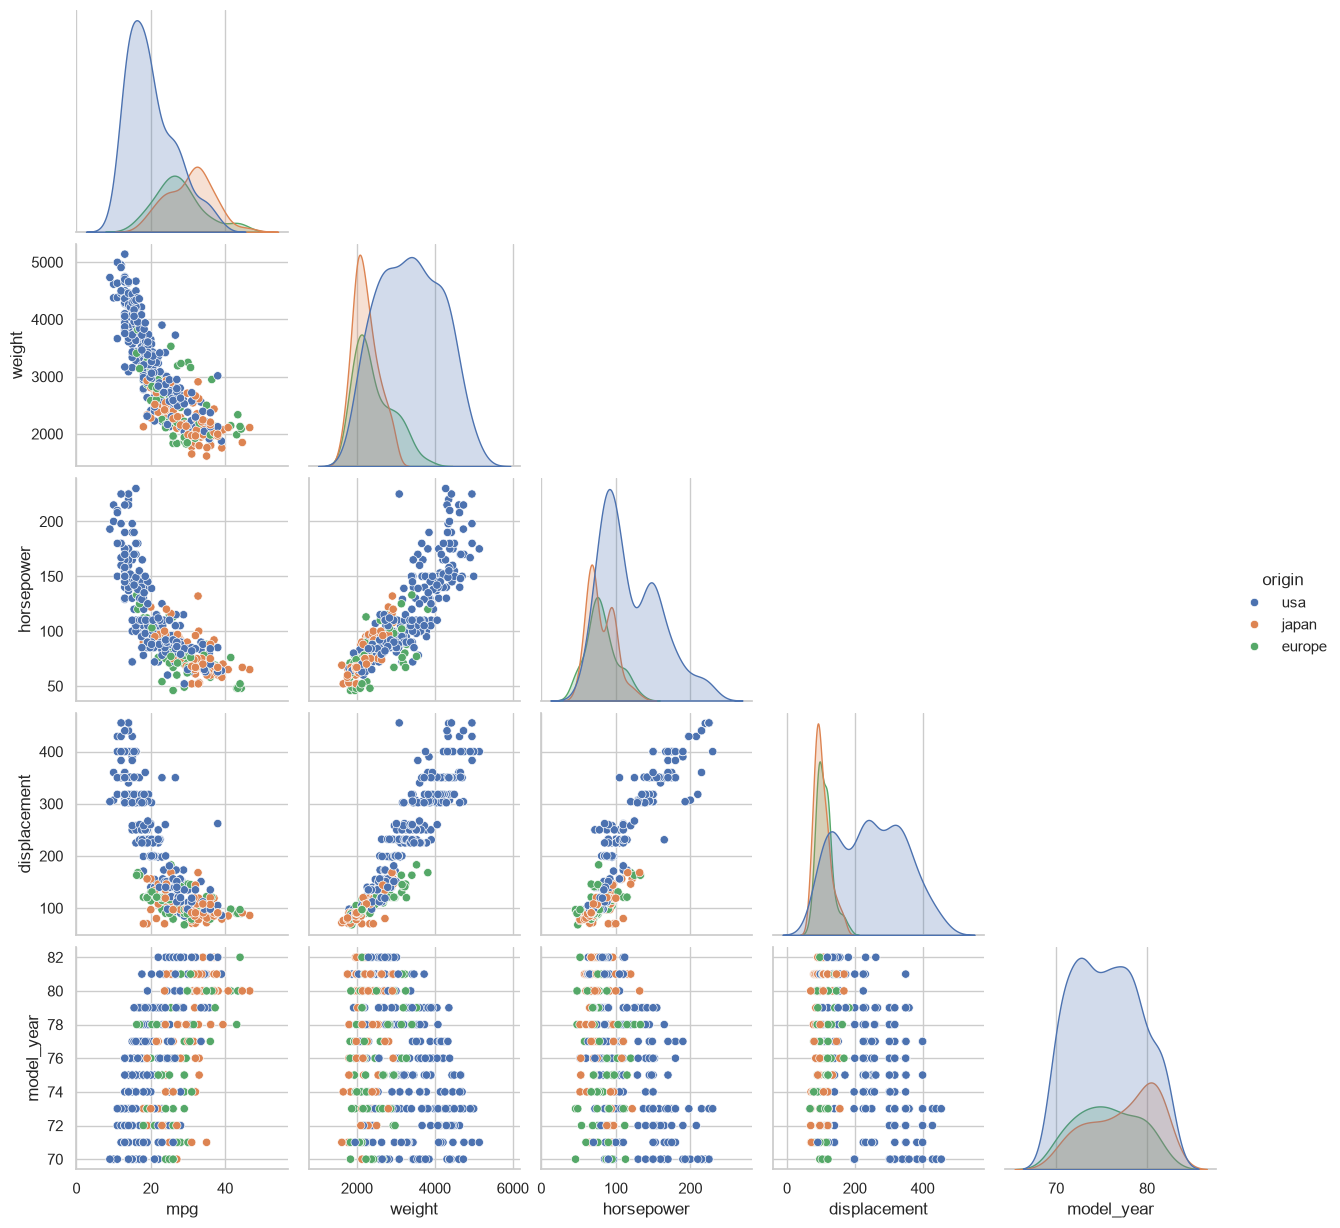

In [164]:
# 24. Construye un `pairplot` con `mpg`, `weight`, `horsepower`, `displacement` y
# `model_year`, usando `origin` como color.

pair_plot = df[["mpg", "weight", "horsepower", "displacement", "model_year","origin"]].dropna()
sns.pairplot(pair_plot, vars=["mpg", "weight", "horsepower", "displacement", "model_year"], hue="origin", corner=True)
plt.show()

In [ ]:
# 25. Elabora un “registro de decisiones” para preparar un análisis posterior: decide qué harías
# con los nulos de `horsepower`, `name`, `origin`, los outliers de potencia y las variables
# altamente correlacionadas.
# Pista de trabajo: Distingue entre decisiones para EDA y decisiones para modelado; una variable útil para
# interpretar puede no ser adecuada como predictor directo.

# los nulos de horsepower los eliminaria para el modelado. Pero para el eda pondria la media para que no modifique su promedio y pueda usar los otros datos
# los outlaiers seria con iqr porque agrupalos casos de z-score
# las variables altamente correlacionadas para el modelado usaria la que tiene mayor correlacion con mpg.

